In [61]:
import functools
import os

from astropy.coordinates import SkyCoord, ICRS, get_body
from astropy.time import Time
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib.transforms as mtrans
import numpy as np
# For Helioprojective treatment
import sunpy.coordinates

from punchbowl.data import load_ndcube_from_fits
from punchbowl.data.visualize import cmap_punch

In [6]:
PATH_TO_DATA = '/home/samuel.vankooten/wispr_analysis_/wispr_analysis/data'

In [59]:
# This is a subjective list of nice constellations to plot, though it's not being actively used
GOOD_CONSTELLATIONS = [
    'Andromeda',
    'Aquarius',
    'Aquila',
    'Aries',
    'Bootes',
    'Cancer',
    'Carina',
    'Canis Major',
    'Capricornus',
    'Cassiopeia',
    'Centaurus',
    'Cetus',
    'Cygnus',
    'Draco',
    'Eridanus',
    'Gemini',
    'Hercules',
    'Hydra',
    'Leo',
    'Libra',
    'Lupus',
    'Monoceros',
    'Ophiuchus',
    'Orion',
    'Pegasus',
    'Phoenix',
    'Pisces',
    'Sagittarius',
    'Scorpius',
    'Serpens',
    'Taurus',
    'Ursa Major',
    'Ursa Minor',
    'Virgo',
    ]


@functools.cache
def load_constellation_data():    
    name_dat = open(
        os.path.join(PATH_TO_DATA, "constellation_names.eng.fab")).readlines()
    # Maps constellation abbreviations to full names
    name_map = {line.split()[0]: line.split('"')[1] for line in name_dat}

    star_dat = open(
        os.path.join(PATH_TO_DATA, "hipparchos_catalog.tsv")).readlines()
    # Will map Hipparchos IDs to (RA, Dec)
    star_map = {}
    for line in star_dat[43:-1]:
        try:
            id, RA, dec, Vmag = line.split(";")
        except ValueError:
            continue
        try:
            if float(Vmag) > 6.7:
                continue
        except ValueError:
            continue
        star_map[id.strip()] = (RA, dec)

    line_dat = open(
        os.path.join(PATH_TO_DATA, "constellationship.fab")).readlines()
    # Will map constellation name to a list of star pairs defining each line
    line_dict = {}
    # We'll keep all the RAs and decs we need for constellations here, so later
    # we can run all the coordinate transformations at once (much faster!)
    RAs, decs = [], []
    # This maps a Hipparcos ID to a position in the RA/dec lists
    id_to_elem = {}
    for const in line_dat:
        pieces = const.split()
        name = name_map[pieces[0]]
        star_ids = pieces[2:]
        for id in star_ids:
            if id not in id_to_elem:
                id_to_elem[id] = len(RAs)
                RA, dec = star_map[id]
                RAs.append(RA)
                decs.append(dec)
        star_elem_ids = [id_to_elem[id] for id in star_ids]
        line_dict[name] = list(zip(star_elem_ids[::2], star_elem_ids[1::2]))
    RAs = np.array(RAs)
    decs = np.array(decs)
    distances = np.full(len(RAs), 1e10)
    coords = SkyCoord(
        RAs, decs, distances, frame=ICRS, unit=(u.hourangle, u.deg, u.lightyear))
    return line_dict, coords
    
    
def plot_constellations(wcs, ax=None, text_alpha=0.7, text_color='#ffe282',
                        line_alpha=0.7, line_width=0.4,
                        line_color='#ffe282'):
    if ax is None:
        ax = plt.gca()
    
    constellations, coords = load_constellation_data()
    xs, ys = wcs.world_to_pixel(coords)
    
    # When a line segment goes off the edge of the image, we want to plot it,
    # but we don't want to push out the axis bounds. So we capture and later
    # restore the current axis bounds.
    ax.autoscale()
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    
    for name, pairs in constellations.items():
        ra_all = []
        dec_all = []
        n_good = 0
        if len(pairs) < 2:
            # Skip the really small, trivial constellations
            continue
        for istart, istop in pairs:
            start = xs[istart], ys[istart]
            stop = xs[istop], ys[istop]
            if not np.all(np.isfinite(start)) or not np.all(np.isfinite(stop)):
                continue
            for coord in (coords[istart], coords[istop]):
                ra_all.append(coord.ra)
                dec_all.append(coord.dec)
            
            p1good = (xlim[0] <= start[0] <= xlim[1]
                      and ylim[0] <= start[1] <= ylim[1])
            p2good = (xlim[0] <= stop[0] <= xlim[1]
                      and ylim[0] <= stop[1] <= ylim[1])
            # Skip this segment if neither end is in the plot
            if p1good or p2good:
                ax.plot(
                    [start[0], stop[0]],
                    [start[1], stop[1]],
                    color=line_color, linewidth=line_width, alpha=line_alpha)
                n_good += 1
        if n_good > 0:
            ra = np.mean(u.Quantity(ra_all))
            dec = np.mean(u.Quantity(dec_all))
            x, y = wcs.world_to_pixel(SkyCoord(
                ra, dec, 1e10 * u.lightyear, frame=ICRS))
            text = ax.text(
                x, y,
                name,
                # Ensure the text isn't drawn outside the axis bounds
                clip_on=True,
                color=text_color, alpha=text_alpha)
            # Don't let text that falls outside the axis bounds affect the size
            # of the whole figure
            text.set_in_layout(False)
            # Ensure the text is clipped at exactly the edge of the axes
            text.set_clip_box(
                mtrans.TransformedBbox(
                    mtrans.Bbox([[0,0], [1,1]]),
                    ax.transAxes))
    # Restore the axis bounds
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

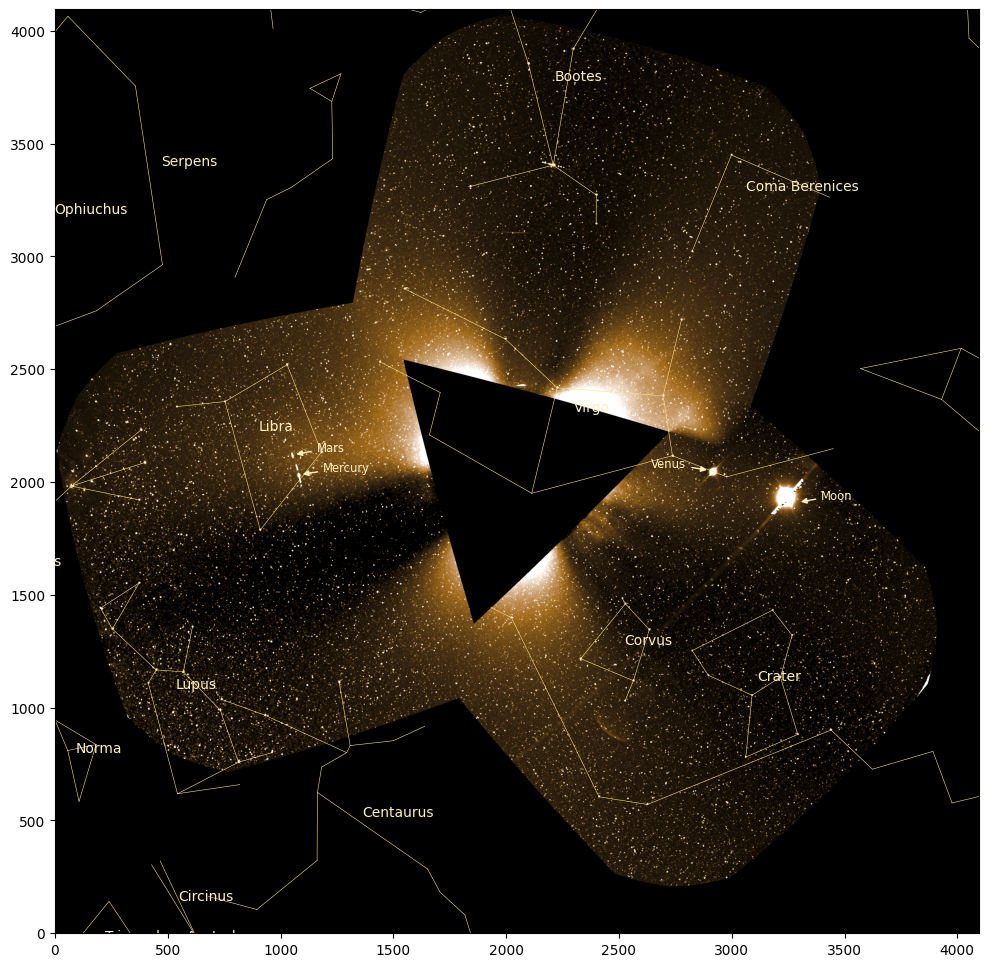

In [78]:
# The WCS needs to have the correct date and observer location so it can do the celestial -> helio conversion
cube = load_ndcube_from_fits('/d0/punchsoc/real_data/3/PIM/2025/10/19/PUNCH_L3_PIM_20251019000230_v0i.fits')

tb = 2/3 * np.sum(cube.data, axis=0)
star_wcs = cube.wcs.celestial
my_image_shape = tb.shape
good_pixels = (cube.data[0] != 0) + np.isfinite(cube.uncertainty.array[0])

plt.figure(figsize=(12,12))
plt.imshow(tb, vmin=0, vmax=3e-13, cmap=cmap_punch, origin='lower')

# Draw the constellations
plot_constellations(star_wcs, text_alpha=1, text_color='#fff0bd', line_alpha=1)

# Mark planets
bodies = ['Mercury', 'Venus', 'Moon', 'Mars', 'Jupiter', 'Saturn']
for body in bodies:
    body_loc = get_body(body, time=Time(star_wcs.wcs.dateobs))
    x, y = star_wcs.world_to_pixel(body_loc)
    # Don't mark planets that fall outside the image, or in the masked portion of the image
    if (0 < x < my_image_shape[1] and 0 < y < my_image_shape[0]
            and good_pixels[int(y), int(x)]):
        # Where should the label be relative to the planet
        dx = 5
        dy = 5
        
        # Left alignment means the left edge of the label is at the given coordinate, so the label extends to the right.
        # For planets at the right edge of the FOV, you'll want right alignment so the label goes to the left instead.
        alignment = 'left'
        xytext = (2, .3)
        
        # Special cases as needed
        if body == 'Moon':
            dx = 15 if x > 1024 else 40
            dy = 5
        if body == 'Venus':
            # Venus was at the edge of the FOV for this run
            alignment = 'right'
            dx = -15
            xytext = (-2, .3)
        
        an = plt.annotate(body,(x+dx, y+dy), xytext,
                        textcoords='offset fontsize',
                        fontsize='small',
                        color='#fff0bd',
                        annotation_clip=True,
                        horizontalalignment=alignment,
                        arrowprops=dict(
                            edgecolor='#fff0bd',
                            facecolor='#fff0bd',
                            arrowstyle='-|>'))
        # These were attempts to handle things better when planets are at the very edges, but they didn't seem to help.
        # This seems like it just hides the annotations
        # for a in [an, an.arrow_patch]:
            # a.set_in_layout(False)
            # Ensure the text is clipped at exactly the edge of the axes
            # a.set_clip_box(
            #     mtrans.TransformedBbox(
            #         mtrans.Bbox([[0,0], [1,1]]),
            #         plt.gca().transData))
            # a.set_clip_on(True)